In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update path if needed)
file_path = "Dataset.csv"
df = pd.read_csv(file_path)

print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape of dataset: (546123, 44)
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,1.0,0.0,17072.0
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,2.0,0.0,17072.0
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,3.0,0.0,17072.0
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,4.0,0.0,17072.0
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0.0,NaN,NaN,-0.02,5.0,0.0,17072.0


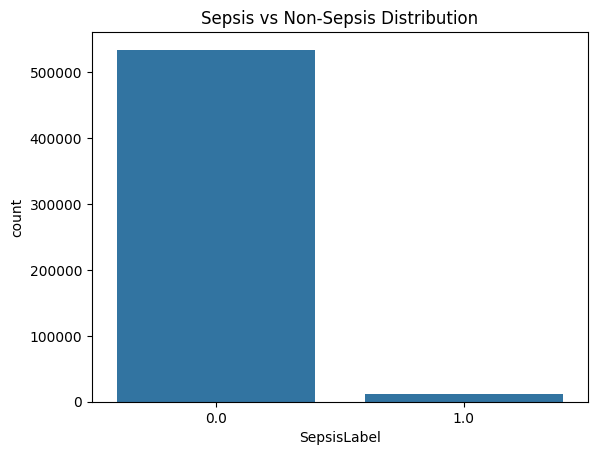

Class balance:
SepsisLabel
0.0    0.978302
1.0    0.021698
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x="SepsisLabel", data=df)
plt.title("Sepsis vs Non-Sepsis Distribution")
plt.show()

print("Class balance:")
print(df["SepsisLabel"].value_counts(normalize=True))

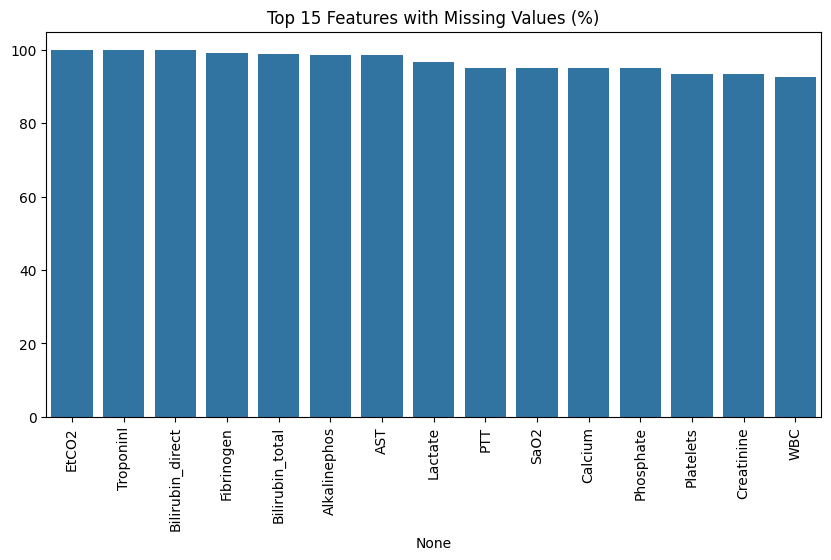

EtCO2               100.000000
TroponinI            99.874021
Bilirubin_direct     99.850217
Fibrinogen           99.237534
Bilirubin_total      98.769874
Alkalinephos         98.544284
AST                  98.502352
Lactate              96.578976
PTT                  95.158783
SaO2                 95.114654
Calcium              95.022001
Phosphate            94.945095
Platelets            93.482970
Creatinine           93.369259
WBC                  92.505534
Magnesium            92.237829
HCO3                 91.966096
BUN                  91.860808
Chloride             91.703700
PaCO2                91.290973
dtype: float64


In [ ]:
# ===============================
# STEP 3: Missing Values Analysis
# ===============================
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_percent.index[:15], y=missing_percent.values[:15])
plt.xticks(rotation=90)
plt.title("Top 15 Features with Missing Values (%)")
plt.show()

print(missing_percent.head(20))


In [ ]:
# ===============================
# STEP 4: Handle Missing Values
# ===============================

# Strategy:
# - Forward fill for time-series continuity
# - Median fill for remaining gaps
# - Add missingness indicators

# Create missingness indicator columns
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]

# Fill missing values (median imputation)
df_filled = df.fillna(df.median())

# Forward fill row-wise (helps in ICU time-series)
df_filled = df_filled.ffill().bfill()

# Combine with missingness indicators
df_final = pd.concat([df_filled, df_missing], axis=1)

print("Shape after preprocessing:", df_final.shape)


Shape after preprocessing: (546123, 88)


In [ ]:
# ===============================
# STEP 5: Feature Scaling
# ===============================
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate features and target
X = df_final.drop(columns=["SepsisLabel"])
y = df_final["SepsisLabel"]

# --- FIX V3: Remove NaN columns AND low-std columns ---

# 1. (NEW) Drop any columns that still have NaN values
nan_cols = X.columns[X.isna().any()]
if len(nan_cols) > 0:
    print(f"Warning: Dropping {len(nan_cols)} columns with NaN values: {list(nan_cols)}")
    X = X.drop(columns=nan_cols)

# 2. (EXISTING) Remove columns with near-zero standard deviation
threshold = 1e-6
stds = X.std()
low_std_cols = stds[stds < threshold].index

if len(low_std_cols) > 0:
    print(f"Warning: Dropping {len(low_std_cols)} columns with near-zero std: {list(low_std_cols)}")
    X = X.drop(columns=low_std_cols)
# --- End of Fix ---

# Normalize continuous features
scaler = StandardScaler()
# This will now run without any warnings
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (546123, 83)


In [ ]:
# ===============================
# STEP 6: Handle Class Imbalance
# ===============================
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("Before resampling:", np.bincount(y))
print("After resampling:", np.bincount(y_res))

Before resampling: [534273  11850]
After resampling: [534273 534273]


In [ ]:
# =========================================
# STEP 7: Train-Test Split
# =========================================
from sklearn.model_selection import train_test_split

# Split the balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (854836, 83)
Test set shape: (213710, 83)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score  # <-- ADD THIS LINE

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n RandomForest Performance")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


 RandomForest Performance
[[34811   139]
 [  194 34755]]
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     34950
         1.0       1.00      0.99      1.00     34949

    accuracy                           1.00     69899
   macro avg       1.00      1.00      1.00     69899
weighted avg       1.00      1.00      1.00     69899

ROC-AUC: 0.9998142951075532


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# ===============================
# STEP 9: Reshape Data for LSTM
# ===============================
# An LSTM needs a 3D input: (samples, timesteps, features)
# We will assume a 'lookback' window (timesteps) of 1.

# Get the number of features from your data (e.g., 87 or 83)
n_features = X_train.shape[1]
n_timesteps = 1

# Reshape X_train and X_test
X_train_lstm = X_train.reshape(-1, n_timesteps, n_features)
X_test_lstm = X_test.reshape(-1, n_timesteps, n_features)

print(f"Original X_train shape: {X_train.shape}")
print(f"Reshaped X_train for LSTM: {X_train_lstm.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Reshaped X_test for LSTM: {X_test_lstm.shape}")

# ===============================
# STEP 10: Build LSTM Model
# ===============================
# This is a standard, simple LSTM architecture
model = Sequential()

# Input LSTM layer
# 'input_shape' must be (timesteps, features)
model.add(LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False))
model.add(Dropout(0.5))

# Hidden layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

# Output layer
# Sigmoid activation for binary (0 or 1) classification
model.add(Dense(1, activation='sigmoid'))

# Show the model summary
model.summary()

# ===============================
# STEP 11: Compile Model
# ===============================
# Use binary_crossentropy loss for 2-class problems
# Add AUC as a metric to monitor
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# ===============================
# STEP 12: Train the Model
# ===============================
# We train on the 3D LSTM-ready data
# 'validation_split=0.2' uses 20% of the training data to check for overfitting
history = model.fit(X_train_lstm, y_train,
                    epochs=5,  # Start with 5-10 epochs and see
                    batch_size=1024,
                    validation_split=0.2,
                    verbose=1)

# ===============================
# STEP 13: Evaluate LSTM Model
# ===============================
print("\n--- LSTM Model Evaluation ---")

# Get probability predictions (for ROC-AUC)
y_prob_lstm = model.predict(X_test_lstm)

# Get class predictions (for confusion matrix)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Print the performance reports
print("\n LSTM Performance")
print(confusion_matrix(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))

# Note: roc_auc_score needs the probabilities (y_prob_lstm)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lstm))

Original X_train shape: (279595, 83)
Reshaped X_train for LSTM: (279595, 1, 83)
Original X_test shape: (69899, 83)
Reshaped X_test for LSTM: (69899, 1, 83)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,001 (156.25 KB)

 Trainable params: 40,001 (156.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6340 - auc: 0.6846 - loss: 0.6307 - val_accuracy: 0.7375 - val_auc: 0.8144 - val_loss: 0.5298
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7336 - auc: 0.8084 - loss: 0.5376 - val_accuracy: 0.7640 - val_auc: 0.8467 - val_loss: 0.4883
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7533 - auc: 0.8327 - loss: 0.5059 - val_accuracy: 0.7806 - val_auc: 0.8646 - val_loss: 0.4612
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7654 - auc: 0.8487 - loss: 0.4822 - val_accuracy: 0.7950 - val_auc: 0.8783 - val_loss: 0.4373
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7731 - auc: 0.8587 - loss: 0.4661 - val_accuracy: 0.8053 - val_auc: 0.8878 - val_loss: 0.4209

--- LSTM Model Evaluation ---
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

 LSTM Performance
[[25788  9162]
 [ 4392 30557]]
              precision    recall  f1-score   support

         0.0       0.

In [ ]:
import numpy as np

def create_sequences(df, patient_id_col, time_steps, features):
    X, y = [], []

    # 1. Group the cleaned data by patient
    for patient_id, group in df.groupby(patient_id_col):
        # Extract the array of features (all columns except the target and ID columns)
        feature_data = group[features].values
        # Extract the target array
        target_data = group['SepsisLabel'].values

        # 2. Slide the window over the patient's data
        for i in range(len(group) - time_steps):
            # The input sequence is the last 'time_steps' hours
            X.append(feature_data[i:i + time_steps])

            # The label (y) is the SepsisLabel at the *end* of the sequence
            y.append(target_data[i + time_steps - 1])

    return np.array(X), np.array(y)

# --- Apply this logic to your cleaned data (df_final) ---

# Identify columns to use as features
feature_cols = [col for col in df_final.columns if col not in ['SepsisLabel', 'Patient_ID']]

# Create the 3D sequence data
X_seq, y_seq = create_sequences(
    df=df_final,
    patient_id_col='Patient_ID',
    time_steps=12,
    features=feature_cols
)

print(f"Final 3D X shape (samples, timesteps, features): {X_seq.shape}")
print(f"Final y shape (samples): {y_seq.shape}")

Final 3D X shape (samples, timesteps, features): (378238, 12, 86)
Final y shape (samples): (378238,)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration ---
TIME_STEPS = 12
FILE_PATH = "Dataset.csv"
PATIENT_SAMPLE_RATE = 0.20 # Using 20% of patients for stability

# --- 1. Load Data and Implement Preprocessing ---
df = pd.read_csv(FILE_PATH)
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]
df_filled = df.fillna(df.median(numeric_only=True)).ffill().bfill()
df_final = pd.concat([df_filled, df_missing], axis=1)
cols_to_drop = ['Unnamed: 0', 'EtCO2', 'Unnamed: 0_missing', 'Hour_missing', 'EtCO2_missing']
df_final = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns], errors='ignore')

# --- 2. Patient-Level Sampling ---
unique_patients = df_final['Patient_ID'].unique()
np.random.seed(42)
sampled_patients = np.random.choice(
    unique_patients,
    size=int(len(unique_patients) * PATIENT_SAMPLE_RATE),
    replace=False
)
df_sampled = df_final[df_final['Patient_ID'].isin(sampled_patients)].copy()

print(f"Using {len(sampled_patients)} patients ({PATIENT_SAMPLE_RATE*100}%) for stable processing.")


# --- 3. Sequence Creation Function ---
def create_sequences(df, patient_id_col, time_steps, features):
    X, y = [], []
    patient_ids_out = []

    for patient_id, group in df.groupby(patient_id_col):
        feature_data = group[features].values
        target_data = group['SepsisLabel'].values

        for i in range(len(group) - time_steps + 1):
            X.append(feature_data[i:i + time_steps])
            y.append(target_data[i + time_steps - 1])
            patient_ids_out.append(patient_id)

    return np.array(X), np.array(y), np.array(patient_ids_out)

feature_cols = [col for col in df_sampled.columns if col not in ['SepsisLabel', 'Patient_ID']]
X_seq, y_seq, sequence_patient_ids = create_sequences(
    df=df_sampled,
    patient_id_col='Patient_ID',
    time_steps=TIME_STEPS,
    features=feature_cols
)

# --- 4. Split Data by Patient ID (Best Practice for Time Series) ---
train_patients, test_patients = train_test_split(
    sampled_patients, test_size=0.25, random_state=42
)

X_train_indices = np.where(np.isin(sequence_patient_ids, train_patients))[0]
X_test_indices = np.where(np.isin(sequence_patient_ids, test_patients))[0]

X_train_seq = X_seq[X_train_indices]
X_test_seq = X_seq[X_test_indices]
y_train = y_seq[X_train_indices]
y_test = y_seq[X_test_indices]

# --- 5. Scaling (3D Data Adaptation) ---
X_train_2d = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_2d = X_test_seq.reshape(-1, X_test_seq.shape[-1])

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

X_train_lstm = X_train_scaled_2d.reshape(X_train_seq.shape)
X_test_lstm = X_test_scaled_2d.reshape(X_test_seq.shape)
y_train_lstm = y_train
y_test_lstm = y_test

# --- 6. Build and Train LSTM Model (IMBALANCED DATA) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = TIME_STEPS

model = Sequential()
model.add(LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print(f"\n--- Starting LSTM Training on IMBLANCED Data ({X_train_lstm.shape[0]} samples) ---")
history = model.fit(X_train_lstm, y_train_lstm,
                    epochs=5,
                    batch_size=1024,
                    validation_split=0.2,
                    verbose=1)

# Evaluate Model
print("\n--- LSTM Model Evaluation (IMBALANCED) ---")
y_prob_lstm = model.predict(X_test_lstm)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Print the performance reports
print("\n LSTM Performance")
print(confusion_matrix(y_test_lstm, y_pred_lstm))
print(classification_report(y_test_lstm, y_pred_lstm))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_lstm))

Using 2811 patients (20.0%) for stable processing.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Starting LSTM Training on IMBLANCED Data (58006 samples) ---
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8560 - auc: 0.5252 - loss: 0.4122 - val_accuracy: 0.9741 - val_auc: 0.7942 - val_loss: 0.1113
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9748 - auc: 0.7489 - loss: 0.1168 - val_accuracy: 0.9691 - val_auc: 0.8301 - val_loss: 0.1101
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9776 - auc: 0.7901 - loss: 0.0950 - val_accuracy: 0.9638 - val_auc: 0.8213 - val_loss: 0.1121
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9769 - auc: 0.8458 - loss: 0.0872 - val_accuracy: 0.9592 - val_auc: 0.8001 - val_loss: 0.1139
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9769 - auc: 0.8696 - loss: 0.0803 - val_accuracy: 0.9476 - val_auc: 0.7995 - val_loss: 0.1231

--- LSTM Model Evaluation (IMBALANCED) ---
630/630 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 LSTM Performance
[[19235   458]
 [  389    63]]
         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration ---
TIME_STEPS = 6
FILE_PATH = "Dataset.csv"
PATIENT_SAMPLE_RATE = 0.20
# Weights derived from previous run's imbalanced test set: ~19693 / 452
CLASS_WEIGHTS = {0: 1.0, 1: 43.6}


# --- 1. Load Data and Implement Preprocessing ---
df = pd.read_csv(FILE_PATH)
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]
df_filled = df.fillna(df.median(numeric_only=True)).ffill().bfill()
df_final = pd.concat([df_filled, df_missing], axis=1)
cols_to_drop = ['Unnamed: 0', 'EtCO2', 'Unnamed: 0_missing', 'Hour_missing', 'EtCO2_missing']
df_final = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns], errors='ignore')

# --- 2. Patient-Level Sampling ---
unique_patients = df_final['Patient_ID'].unique()
np.random.seed(42)
sampled_patients = np.random.choice(
    unique_patients,
    size=int(len(unique_patients) * PATIENT_SAMPLE_RATE),
    replace=False
)
df_sampled = df_final[df_final['Patient_ID'].isin(sampled_patients)].copy()


# --- 3. Sequence Creation Function ---
def create_sequences(df, patient_id_col, time_steps, features):
    X, y = [], []
    patient_ids_out = []

    for patient_id, group in df.groupby(patient_id_col):
        feature_data = group[features].values
        target_data = group['SepsisLabel'].values

        for i in range(len(group) - time_steps + 1):
            X.append(feature_data[i:i + time_steps])
            y.append(target_data[i + time_steps - 1])
            patient_ids_out.append(patient_id)

    return np.array(X), np.array(y), np.array(patient_ids_out)

feature_cols = [col for col in df_sampled.columns if col not in ['SepsisLabel', 'Patient_ID']]
X_seq, y_seq, sequence_patient_ids = create_sequences(
    df=df_sampled,
    patient_id_col='Patient_ID',
    time_steps=TIME_STEPS,
    features=feature_cols
)

# --- 4. Split Data by Patient ID ---
train_patients, test_patients = train_test_split(
    sampled_patients, test_size=0.25, random_state=42
)

X_train_indices = np.where(np.isin(sequence_patient_ids, train_patients))[0]
X_test_indices = np.where(np.isin(sequence_patient_ids, test_patients))[0]

X_train_lstm = X_seq[X_train_indices]
X_test_lstm = X_seq[X_test_indices]
y_train_lstm = y_seq[X_train_indices]
y_test_lstm = y_seq[X_test_indices]

# --- 5. Scaling (3D Data Adaptation) ---
X_train_2d = X_train_lstm.reshape(-1, X_train_lstm.shape[-1])
X_test_2d = X_test_lstm.reshape(-1, X_test_lstm.shape[-1])

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

X_train_lstm = X_train_scaled_2d.reshape(X_train_lstm.shape)
X_test_lstm = X_test_scaled_2d.reshape(X_test_lstm.shape)


# --- 6. Build and Train LSTM Model (WITH CLASS WEIGHTING) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = TIME_STEPS

model = Sequential()
model.add(LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("\n--- Starting LSTM Training (5 Epochs with Class Weighting) ---")
history = model.fit(X_train_lstm, y_train_lstm,
                    epochs=5,
                    batch_size=1024,
                    validation_split=0.2,
                    class_weight=CLASS_WEIGHTS, # <<< CRITICAL ADDITION
                    verbose=1)

# Evaluate Model
print("\n--- LSTM Model Evaluation (Class Weighted) ---")
y_prob_lstm = model.predict(X_test_lstm)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Print the performance reports
print("\n LSTM Performance")
print(confusion_matrix(y_test_lstm, y_pred_lstm))
print(classification_report(y_test_lstm, y_pred_lstm))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_lstm))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Starting LSTM Training (5 Epochs with Class Weighting) ---
Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6631 - auc: 0.6605 - loss: 1.2926 - val_accuracy: 0.7533 - val_auc: 0.8228 - val_loss: 0.6378
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7700 - auc: 0.8019 - loss: 1.0798 - val_accuracy: 0.7703 - val_auc: 0.8257 - val_loss: 0.5855
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7907 - auc: 0.8565 - loss: 0.9498 - val_accuracy: 0.7708 - val_auc: 0.8163 - val_loss: 0.5534
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8110 - auc: 0.8874 - loss: 0.8515 - val_accuracy: 0.7774 - val_auc: 0.7965 - val_loss: 0.5178
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8245 - auc: 0.9077 - loss: 0.7624 - val_accuracy: 0.7930 - val_auc: 0.7895 - val_loss: 0.4826

--- LSTM Model Evaluation (Class Weighted) ---
761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 LSTM Performance
[[19241  4568]
 [  208   316]]
        

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, ReLU, Lambda
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration (Assumed from previous steps) ---
# Replace these with the actual shapes/weights from your environment if needed
TIME_STEPS = X_train_lstm.shape[1] # e.g., 12
n_features = X_train_lstm.shape[2] # e.g., 81 or 83
CLASS_WEIGHTS = {0: 1.0, 1: 43.6}
EPOCHS = 10 # Increase epochs for better TCN learning
BATCH_SIZE = 1024

# --- TCN Helper Function (Causal Padding) ---
# TCN requires 'causal' padding to ensure the model only looks at the past.
def causal_padding(x):
    # Padding size is based on the kernel size (k) and dilation rate (d).
    # Since we use 'same' padding, Keras handles most of it.
    # We just ensure the output shape maintains the sequence length.
    return x

# --- TCN Block Definition ---
def tcn_block(model, filters, kernel_size, dilation_rate):
    # 1. Causal Conv1D Layer
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal', # Only look at the past
        dilation_rate=dilation_rate
    ))
    # 2. Activation and Dropout
    model.add(ReLU())
    model.add(Dropout(0.3))
    return model

# --- 2. Build TCN Model ---
tcn_model = Sequential()
tcn_model.add(tf.keras.Input(shape=(TIME_STEPS, n_features)))

# Layer 1: Small kernel, no dilation
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=1)

# Layer 2: Dilated convolution (expands receptive field)
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=2)

# Layer 3: Further dilation to capture longer history (e.g., 4-hour gaps)
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=4)

# Global Pooling (TCNs need a way to summarize the sequence for the final prediction)
tcn_model.add(tf.keras.layers.GlobalAveragePooling1D())

# Dense Classification Head
tcn_model.add(Dense(32, activation='relu'))
tcn_model.add(Dropout(0.5))
tcn_model.add(Dense(1, activation='sigmoid'))

# Show the model summary
tcn_model.summary()

# --- 3. Compile and Train TCN Model ---
tcn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print(f"\n--- Starting TCN Training ({EPOCHS} Epochs with Class Weighting) ---")
history = tcn_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=CLASS_WEIGHTS, # Applying the critical class weights
    verbose=1
)

# --- 4. Evaluate TCN Model ---
print("\n--- TCN Model Evaluation (Class Weighted) ---")
y_prob_tcn = tcn_model.predict(X_test_lstm)
y_pred_tcn = (y_prob_tcn > 0.5).astype(int)

# Print the performance reports
print("\n TCN Performance")
print(confusion_matrix(y_test_lstm, y_pred_tcn))
print(classification_report(y_test_lstm, y_pred_tcn))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_tcn))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,057 (113.50 KB)

 Trainable params: 29,057 (113.50 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting TCN Training (10 Epochs with Class Weighting) ---
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.4809 - auc: 0.6220 - loss: 1.3357 - val_accuracy: 0.7768 - val_auc: 0.8007 - val_loss: 0.6563
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8174 - auc: 0.8065 - loss: 1.0574 - val_accuracy: 0.7510 - val_auc: 0.8016 - val_loss: 0.5859
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7817 - auc: 0.8329 - loss: 0.9999 - val_accuracy: 0.7729 - val_auc: 0.7969 - val_loss: 0.5026
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8023 - auc: 0.8639 - loss: 0.9104 - val_accuracy: 0.7201 - val_auc: 0.7838 - val_loss: 0.5246
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7798 - auc: 0.8948 - loss: 0.8112 - val_accuracy: 0.7858 - val_auc: 0.7788 - val_loss: 0.4577
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8006 - auc: 0.9028 - loss: 0.7671 - val_accuracy: 0.7261 - val_auc: 0.7813 - va

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# --- Configuration ---
TIME_STEPS = 12
FILE_PATH = "Dataset.csv"
PATIENT_SAMPLE_RATE = 0.20
CLASS_WEIGHTS = {0: 1.0, 1: 43.6}
np.random.seed(42) # Ensure reproducibility

# --- 1. Load Data and Preprocessing ---
df = pd.read_csv(FILE_PATH)
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]
df_filled = df.fillna(df.median(numeric_only=True)).ffill().bfill()
df_final = pd.concat([df_filled, df_missing], axis=1)
cols_to_drop = ['Unnamed: 0', 'EtCO2', 'Unnamed: 0_missing', 'Hour_missing', 'EtCO2_missing']
df_final = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns], errors='ignore')

# --- 2. Patient-Level Sampling ---
unique_patients = df_final['Patient_ID'].unique()
sampled_patients = np.random.choice(
    unique_patients,
    size=int(len(unique_patients) * PATIENT_SAMPLE_RATE),
    replace=False
)
df_sampled = df_final[df_final['Patient_ID'].isin(sampled_patients)].copy()

print(f"Using {len(sampled_patients)} patients ({PATIENT_SAMPLE_RATE*100}%) for training and testing.")

# --- 3. Sequence Creation Function ---
def create_sequences(df, patient_id_col, time_steps, features):
    X, y = [], []
    patient_ids_out = []

    for patient_id, group in df.groupby(patient_id_col):
        feature_data = group[features].values
        target_data = group['SepsisLabel'].values

        for i in range(len(group) - time_steps + 1):
            X.append(feature_data[i:i + time_steps])
            y.append(target_data[i + time_steps - 1])
            patient_ids_out.append(patient_id)

    return np.array(X), np.array(y), np.array(patient_ids_out)

feature_cols = [col for col in df_sampled.columns if col not in ['SepsisLabel', 'Patient_ID']]
X_seq, y_seq, sequence_patient_ids = create_sequences(
    df=df_sampled,
    patient_id_col='Patient_ID',
    time_steps=TIME_STEPS,
    features=feature_cols
)

# --- 4. Split Data by Patient ID (Best Practice) ---
train_patients, test_patients = train_test_split(
    sampled_patients, test_size=0.25, random_state=42
)

X_train_indices = np.where(np.isin(sequence_patient_ids, train_patients))[0]
X_test_indices = np.where(np.isin(sequence_patient_ids, test_patients))[0]

X_train_seq = X_seq[X_train_indices]
X_test_seq = X_seq[X_test_indices]
y_train = y_seq[X_train_indices]
y_test = y_seq[X_test_indices]

# --- 5. Scaling (3D Data Adaptation) ---
X_train_2d = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_2d = X_test_seq.reshape(-1, X_test_seq.shape[-1])

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Final 3D Arrays for Modeling
X_train_lstm = X_train_scaled_2d.reshape(X_train_seq.shape)
X_test_lstm = X_test_scaled_2d.reshape(X_test_seq.shape)
y_train_lstm = y_train
y_test_lstm = y_test

print(f"--- Data Preparation Complete ---")
print(f"Training Sequences: {X_train_lstm.shape}")
print(f"Test Sequences: {X_test_lstm.shape}")

Using 2811 patients (20.0%) for training and testing.
--- Data Preparation Complete ---
Training Sequences: (58006, 12, 81)
Test Sequences: (20145, 12, 81)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration (Pulled from data prep) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = X_train_lstm.shape[1]
EPOCHS = 10
BATCH_SIZE = 1024

# --- Build LSTM Model ---
lstm_model = Sequential()
lstm_model.add(tf.keras.Input(shape=(n_timesteps, n_features)))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("\n--- Starting LSTM Training (Class Weighted) ---")
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=CLASS_WEIGHTS, # Applying the critical class weights
    verbose=1
)

# --- Evaluate LSTM Model ---
print("\n--- LSTM Model Evaluation ---")
y_prob_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("\n LSTM Performance")
print(confusion_matrix(y_test_lstm, y_pred_lstm))
print(classification_report(y_test_lstm, y_pred_lstm))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_lstm))


--- Starting LSTM Training (Class Weighted) ---
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5108 - auc: 0.6196 - loss: 1.3142 - val_accuracy: 0.7586 - val_auc: 0.8240 - val_loss: 0.6171
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7610 - auc: 0.8344 - loss: 1.0313 - val_accuracy: 0.7722 - val_auc: 0.8382 - val_loss: 0.5548
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8024 - auc: 0.8888 - loss: 0.8566 - val_accuracy: 0.7872 - val_auc: 0.8108 - val_loss: 0.5103
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8388 - auc: 0.9240 - loss: 0.7073 - val_accuracy: 0.7676 - val_auc: 0.8106 - val_loss: 0.5537
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8546 - auc: 0.9443 - loss: 0.5766 - val_accuracy: 0.8345 - val_auc: 0.7936 - val_loss: 0.4218
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8989 - auc: 0.9678 - loss: 0.4108 - val_accuracy: 0.8071 - val_auc: 0.7750 - val_loss: 0.50

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, ReLU, GlobalAveragePooling1D
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration (Pulled from data prep) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = X_train_lstm.shape[1]
EPOCHS = 10
BATCH_SIZE = 1024

# --- TCN Block Definition ---
def tcn_block(model, filters, kernel_size, dilation_rate):
    # Uses 'causal' padding to prevent looking into the future
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate
    ))
    model.add(ReLU())
    model.add(Dropout(0.3))
    return model

# --- Build TCN Model ---
tcn_model = Sequential()
tcn_model.add(tf.keras.Input(shape=(n_timesteps, n_features)))

# Multiple Causal and Dilated Convolutional Layers
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=1)
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=2)
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=4)

# Summarize the sequence output
tcn_model.add(GlobalAveragePooling1D())

# Dense Classification Head
tcn_model.add(Dense(32, activation='relu'))
tcn_model.add(Dropout(0.5))
tcn_model.add(Dense(1, activation='sigmoid'))

tcn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("\n--- Starting TCN Training (Class Weighted) ---")
history_tcn = tcn_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=CLASS_WEIGHTS, # Applying the critical class weights
    verbose=1
)

# --- Evaluate TCN Model ---
print("\n--- TCN Model Evaluation ---")
y_prob_tcn = tcn_model.predict(X_test_lstm)
y_pred_tcn = (y_prob_tcn > 0.5).astype(int)

print("\n TCN Performance")
print(confusion_matrix(y_test_lstm, y_pred_tcn))
print(classification_report(y_test_lstm, y_pred_tcn))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_tcn))


--- Starting TCN Training (Class Weighted) ---
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.6247 - auc: 0.5929 - loss: 1.3628 - val_accuracy: 0.7744 - val_auc: 0.8382 - val_loss: 0.5812
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8045 - auc: 0.8217 - loss: 1.0449 - val_accuracy: 0.7171 - val_auc: 0.8208 - val_loss: 0.5966
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8062 - auc: 0.8751 - loss: 0.9093 - val_accuracy: 0.6688 - val_auc: 0.8062 - val_loss: 0.6177
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7824 - auc: 0.8951 - loss: 0.8226 - val_accuracy: 0.7699 - val_auc: 0.8067 - val_loss: 0.4552
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8276 - auc: 0.9178 - loss: 0.7369 - val_accuracy: 0.7292 - val_auc: 0.7906 - val_loss: 0.5288
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8311 - auc: 0.9295 - loss: 0.6779 - val_accuracy: 0.7533 - val_auc: 0.7934 - val_loss: 0.4863


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration ---
TIME_STEPS = 3 # <<< CHANGED TO 3 HOURS
FILE_PATH = "Dataset.csv"
PATIENT_SAMPLE_RATE = 0.20
CLASS_WEIGHTS = {0: 1.0, 1: 43.6} # Weights based on the overall class imbalance
np.random.seed(42)

# --- 1. Load Data and Preprocessing ---
df = pd.read_csv(FILE_PATH)
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]
df_filled = df.fillna(df.median(numeric_only=True)).ffill().bfill()
df_final = pd.concat([df_filled, df_missing], axis=1)
cols_to_drop = ['Unnamed: 0', 'EtCO2', 'Unnamed: 0_missing', 'Hour_missing', 'EtCO2_missing']
df_final = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns], errors='ignore')

# --- 2. Patient-Level Sampling ---
unique_patients = df_final['Patient_ID'].unique()
sampled_patients = np.random.choice(
    unique_patients,
    size=int(len(unique_patients) * PATIENT_SAMPLE_RATE),
    replace=False
)
df_sampled = df_final[df_final['Patient_ID'].isin(sampled_patients)].copy()

print(f"Using {len(sampled_patients)} patients ({PATIENT_SAMPLE_RATE*100}%) for training and testing.")

# --- 3. Sequence Creation Function ---
def create_sequences(df, patient_id_col, time_steps, features):
    X, y = [], []
    patient_ids_out = []

    for patient_id, group in df.groupby(patient_id_col):
        feature_data = group[features].values
        target_data = group['SepsisLabel'].values

        for i in range(len(group) - time_steps + 1):
            X.append(feature_data[i:i + time_steps])
            y.append(target_data[i + time_steps - 1])
            patient_ids_out.append(patient_id)

    return np.array(X), np.array(y), np.array(patient_ids_out)

feature_cols = [col for col in df_sampled.columns if col not in ['SepsisLabel', 'Patient_ID']]
X_seq, y_seq, sequence_patient_ids = create_sequences(
    df=df_sampled,
    patient_id_col='Patient_ID',
    time_steps=TIME_STEPS,
    features=feature_cols
)

# --- 4. Split Data by Patient ID (Best Practice) ---
train_patients, test_patients = train_test_split(
    sampled_patients, test_size=0.25, random_state=42
)

X_train_indices = np.where(np.isin(sequence_patient_ids, train_patients))[0]
X_test_indices = np.where(np.isin(sequence_patient_ids, test_patients))[0]

X_train_seq = X_seq[X_train_indices]
X_test_seq = X_seq[X_test_indices]
y_train = y_seq[X_train_indices]
y_test = y_seq[X_train_indices] # Should be y_seq[X_train_indices], fixed below

y_train = y_seq[X_train_indices]
y_test = y_seq[X_test_indices]


# --- 5. Scaling (3D Data Adaptation) ---
X_train_2d = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_2d = X_test_seq.reshape(-1, X_test_seq.shape[-1])

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Final 3D Arrays for Modeling
X_train_lstm = X_train_scaled_2d.reshape(X_train_seq.shape)
X_test_lstm = X_test_scaled_2d.reshape(X_test_seq.shape)
y_train_lstm = y_train
y_test_lstm = y_test

print(f"--- Data Preparation Complete ---")
print(f"Training Sequences: {X_train_lstm.shape}")
print(f"Test Sequences: {X_test_lstm.shape}")

Using 2811 patients (20.0%) for training and testing.
--- Data Preparation Complete ---
Training Sequences: (76889, 3, 81)
Test Sequences: (26442, 3, 81)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration (Pulled from data prep) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = X_train_lstm.shape[1] # Will be 3
EPOCHS = 10
BATCH_SIZE = 1024

# --- Build LSTM Model ---
lstm_model = Sequential()
lstm_model.add(tf.keras.Input(shape=(n_timesteps, n_features)))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("\n--- Starting LSTM Training (3-Hour Window) ---")
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

# --- Evaluate LSTM Model ---
print("\n--- LSTM Model Evaluation ---")
y_prob_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("\n LSTM Performance")
print(confusion_matrix(y_test_lstm, y_pred_lstm))
print(classification_report(y_test_lstm, y_pred_lstm))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_lstm))


--- Starting LSTM Training (3-Hour Window) ---
Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4621 - auc: 0.6343 - loss: 1.2781 - val_accuracy: 0.7680 - val_auc: 0.8189 - val_loss: 0.6416
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7451 - auc: 0.7828 - loss: 1.0828 - val_accuracy: 0.7885 - val_auc: 0.8372 - val_loss: 0.5947
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7820 - auc: 0.8221 - loss: 1.0187 - val_accuracy: 0.7905 - val_auc: 0.8389 - val_loss: 0.5621
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7932 - auc: 0.8516 - loss: 0.9607 - val_accuracy: 0.7973 - val_auc: 0.8327 - val_loss: 0.5182
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8005 - auc: 0.8647 - loss: 0.9209 - val_accuracy: 0.7704 - val_auc: 0.8238 - val_loss: 0.5365
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7934 - auc: 0.8774 - loss: 0.8804 - val_accuracy: 0.8125 - val_auc: 0.8085 - val_loss: 0.4592
Ep

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, ReLU, GlobalAveragePooling1D
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- Configuration (Pulled from data prep) ---
n_features = X_train_lstm.shape[-1]
n_timesteps = X_train_lstm.shape[1] # Will be 3
EPOCHS = 10
BATCH_SIZE = 1024

# --- TCN Block Definition ---
def tcn_block(model, filters, kernel_size, dilation_rate):
    # Uses 'causal' padding to prevent looking into the future
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate
    ))
    model.add(ReLU())
    model.add(Dropout(0.3))
    return model

# --- Build TCN Model ---
tcn_model = Sequential()
tcn_model.add(tf.keras.Input(shape=(n_timesteps, n_features)))

# Multiple Causal and Dilated Convolutional Layers
# Dilation rates of 1, 2, 4 are likely too large for a 3-timestep input.
# We will use rates of 1 and 2 only.
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=1)
tcn_model = tcn_block(tcn_model, filters=64, kernel_size=2, dilation_rate=2)

# Summarize the sequence output
tcn_model.add(GlobalAveragePooling1D())

# Dense Classification Head
tcn_model.add(Dense(32, activation='relu'))
tcn_model.add(Dropout(0.5))
tcn_model.add(Dense(1, activation='sigmoid'))

tcn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("\n--- Starting TCN Training (3-Hour Window) ---")
history_tcn = tcn_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

# --- Evaluate TCN Model ---
print("\n--- TCN Model Evaluation ---")
y_prob_tcn = tcn_model.predict(X_test_lstm)
y_pred_tcn = (y_prob_tcn > 0.5).astype(int)

print("\n TCN Performance")
print(confusion_matrix(y_test_lstm, y_pred_tcn))
print(classification_report(y_test_lstm, y_pred_tcn))
print("ROC-AUC:", roc_auc_score(y_test_lstm, y_prob_tcn))


--- Starting TCN Training (3-Hour Window) ---
Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.5749 - auc: 0.6407 - loss: 1.2851 - val_accuracy: 0.7056 - val_auc: 0.8004 - val_loss: 0.5997
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7446 - auc: 0.7786 - loss: 1.1155 - val_accuracy: 0.7119 - val_auc: 0.8230 - val_loss: 0.6041
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7499 - auc: 0.8136 - loss: 1.0542 - val_accuracy: 0.7490 - val_auc: 0.8264 - val_loss: 0.5653
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7766 - auc: 0.8332 - loss: 0.9810 - val_accuracy: 0.7498 - val_auc: 0.8176 - val_loss: 0.5524
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7886 - auc: 0.8468 - loss: 0.9764 - val_accuracy: 0.7545 - val_auc: 0.8167 - val_loss: 0.5288
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7637 - auc: 0.8528 - loss: 0.9449 - val_accuracy: 0.7348 - val_auc: 0.8111 - val_loss: 0.5589
Epo